# NaN Exploration & Imputation for Hockey Tracking Data

The `preprocess.py` position-smoothing step failed because some segments of the tracking data contain NaN values in `Rink Location X (Feet)` / `Y (Feet)`. This notebook:

1. **Audits** how many NaNs exist and where (game, period, player, column)
2. **Characterizes** gap patterns — are they isolated frames or long stretches?
3. **Evaluates** three imputation strategies: ffill/bfill, linear interpolation, and Kalman-predicted bridging
4. **Picks** the best approach and exports an imputed dataset ready for `preprocess.py`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

try:
    from filterpy.kalman import KalmanFilter
    HAS_FILTERPY = True
    print('filterpy available')
except ImportError:
    HAS_FILTERPY = False
    print('filterpy not installed')

tracking = pd.read_parquet('../data/tracking.parquet')

X, Y = 'Rink Location X (Feet)', 'Rink Location Y (Feet)'

# Add game key + elapsed time (same logic as other notebooks)
raw   = tracking['Image Id'].str.extract(r'(^\d{4}-\d{2}-\d{2}.*?)_')[0]
parts = raw.str.extract(r'^(\d{4}-\d{2}-\d{2})\s+(.*?)\s+@\s+(.*)$')
tracking['Game'] = parts[0] + ' ' + parts[2] + ' @ ' + parts[1]
tracking['Period_int'] = pd.to_numeric(tracking['Period'], errors='coerce')

def clk(s):
    try: m, c = s.split(':'); return int(m)*60 + int(c)
    except: return np.nan

tracking['Clock_s']  = tracking['Game Clock'].apply(clk)
tracking['Elapsed_s'] = (tracking['Period_int'] - 1) * 1200 + (1200 - tracking['Clock_s'])

tracking['image_num'] = tracking['Image Id'].str.extract(r'_(\d+)$')[0].astype(float)
tracking = tracking.sort_values(['Game', 'Period_int', 'Player Id', 'image_num']).reset_index(drop=True)

skaters = tracking[tracking['Player or Puck'] == 'Player'].copy()

print(f'Total tracking rows:  {len(tracking):,}')
print(f'Skater rows:          {len(skaters):,}')
print(f'Games:                {tracking["Game"].nunique()}')
print(f'Unique player tracks: {skaters.groupby(["Game","Period_int","Player Id"]).ngroups:,}')

filterpy available
Total tracking rows:  8,401,602
Skater rows:          7,441,848
Games:                10
Unique player tracks: 29,181


## Section 1 — NaN Audit: Scope and Distribution

How many NaNs are there in X and Y, broken down by column, game, period, and player?

=== Skater row NaN summary ===
  X NaNs: 5,452 / 7,441,848  (0.07%)
  Y NaNs: 5,452 / 7,441,848  (0.07%)
  Both NaN: 5,452
  X NaN only: 0
  Y NaN only: 0

=== NaN rate by game (top 10 worst) ===
                      Game     rows  x_nan  y_nan  x_nan_pct
2025-11-28 Team K @ Team J 598117.0  885.0  885.0   0.147964
2025-10-11 Team D @ Team A 844202.0 1005.0 1005.0   0.119047
2025-10-17 Team L @ Team F 742060.0  615.0  615.0   0.082877
2025-10-29 Team L @ Team G 800154.0  660.0  660.0   0.082484
2025-10-24 Team D @ Team E 581321.0  432.0  432.0   0.074314
2025-11-16 Team K @ Team H 517477.0  339.0  339.0   0.065510
2025-11-19 Team K @ Team I 827303.0  482.0  482.0   0.058262
2025-10-24 Team A @ Team B 856989.0  437.0  437.0   0.050992
2025-11-02 Team A @ Team D 833496.0  321.0  321.0   0.038512
2025-10-28 Team A @ Team C 840729.0  276.0  276.0   0.032829

=== NaN rate by period ===
 Period_int  x_nan_pct      rows
        1.0   0.072306 2730081.0
        2.0   0.076640 2593938.0
      

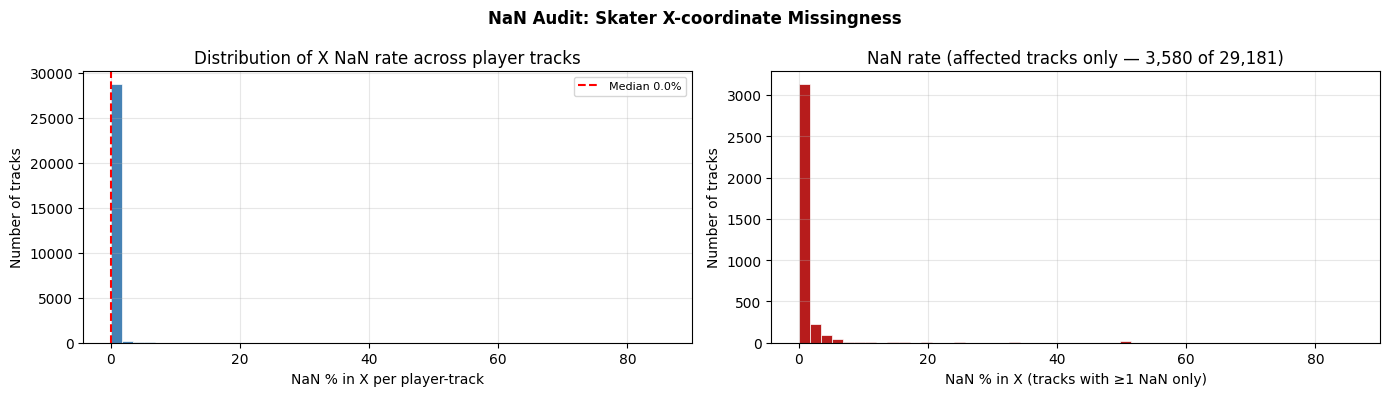

In [2]:
# --- Overall NaN counts ---
nan_x = skaters[X].isna().sum()
nan_y = skaters[Y].isna().sum()
total = len(skaters)
print('=== Skater row NaN summary ===')
print(f'  X NaNs: {nan_x:,} / {total:,}  ({100*nan_x/total:.2f}%)')
print(f'  Y NaNs: {nan_y:,} / {total:,}  ({100*nan_y/total:.2f}%)')
print(f'  Both NaN: {(skaters[X].isna() & skaters[Y].isna()).sum():,}')
print(f'  X NaN only: {(skaters[X].isna() & skaters[Y].notna()).sum():,}')
print(f'  Y NaN only: {(skaters[Y].isna() & skaters[X].notna()).sum():,}')

# --- By game ---
nan_by_game = skaters.groupby('Game').apply(
    lambda g: pd.Series({
        'rows': len(g),
        'x_nan': g[X].isna().sum(),
        'y_nan': g[Y].isna().sum(),
        'x_nan_pct': 100 * g[X].isna().mean(),
    })
).reset_index().sort_values('x_nan_pct', ascending=False)

print(f'\n=== NaN rate by game (top 10 worst) ===')
print(nan_by_game.head(10).to_string(index=False))

# --- By period ---
nan_by_period = skaters.groupby('Period_int').apply(
    lambda g: pd.Series({'x_nan_pct': 100 * g[X].isna().mean(), 'rows': len(g)})
).reset_index()
print(f'\n=== NaN rate by period ===')
print(nan_by_period.to_string(index=False))

# --- Histogram of NaN rate per player-track ---
nan_by_track = skaters.groupby(['Game', 'Period_int', 'Player Id'])[X].apply(
    lambda s: 100 * s.isna().mean()
).reset_index(name='nan_pct')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(nan_by_track['nan_pct'], bins=50, color='steelblue', edgecolor='white', lw=0.5)
axes[0].set_xlabel('NaN % in X per player-track')
axes[0].set_ylabel('Number of tracks')
axes[0].set_title('Distribution of X NaN rate across player tracks')
axes[0].grid(alpha=0.3)
axes[0].axvline(nan_by_track['nan_pct'].median(), color='red', lw=1.5, linestyle='--',
                label=f'Median {nan_by_track["nan_pct"].median():.1f}%')
axes[0].legend(fontsize=8)

# Tracks with any NaN
any_nan = nan_by_track[nan_by_track['nan_pct'] > 0]
axes[1].hist(any_nan['nan_pct'], bins=50, color='#B71C1C', edgecolor='white', lw=0.5)
axes[1].set_xlabel('NaN % in X (tracks with ≥1 NaN only)')
axes[1].set_ylabel('Number of tracks')
axes[1].set_title(f'NaN rate (affected tracks only — {len(any_nan):,} of {len(nan_by_track):,})')
axes[1].grid(alpha=0.3)

plt.suptitle('NaN Audit: Skater X-coordinate Missingness', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 2 — NaN Pattern Analysis

Are gaps isolated single frames, or long stretches? Do they cluster at period boundaries or in specific games?

Total NaN gaps (runs): 4,542
  length=1 (isolated): 4,022  (88.6%)
  length 2–5:          493
  length 6–30:         27
  length >30:          0
  max gap:             11 frames


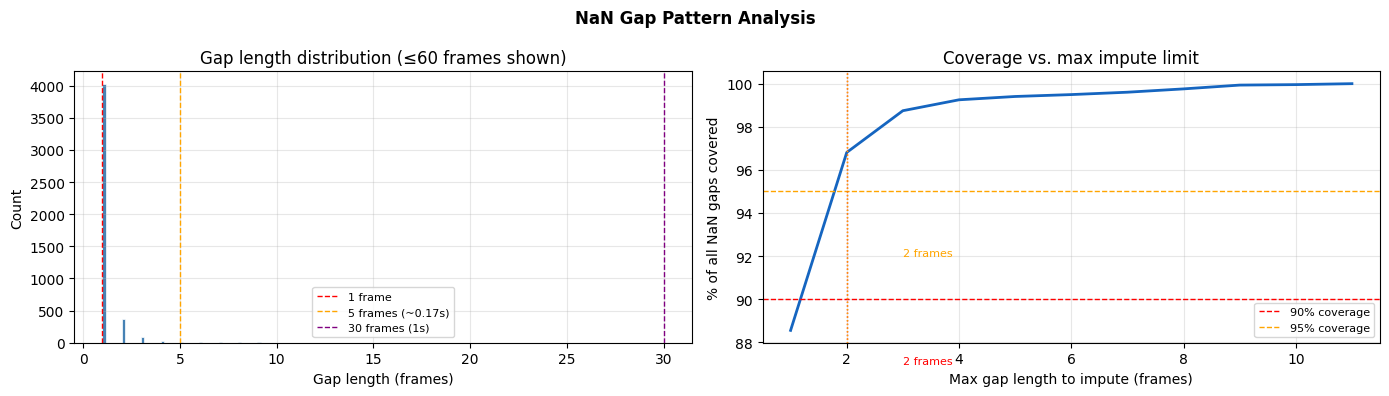

In [3]:
def gap_lengths(series):
    """Return list of consecutive NaN run lengths for a series."""
    gaps = []
    run = 0
    for v in series:
        if pd.isna(v):
            run += 1
        else:
            if run > 0:
                gaps.append(run)
                run = 0
    if run > 0:
        gaps.append(run)
    return gaps

# Compute gap lengths per player track
all_gaps = []
for (game, period, pid), grp in skaters.groupby(['Game', 'Period_int', 'Player Id']):
    # Only consider contiguous frame sequences (frame_diff == 1)
    grp = grp.sort_values('image_num')
    for g in gap_lengths(grp[X].values):
        all_gaps.append(g)

all_gaps = np.array(all_gaps)
print(f'Total NaN gaps (runs): {len(all_gaps):,}')
print(f'  length=1 (isolated): {(all_gaps==1).sum():,}  ({100*(all_gaps==1).mean():.1f}%)')
print(f'  length 2–5:          {((all_gaps>=2)&(all_gaps<=5)).sum():,}')
print(f'  length 6–30:         {((all_gaps>=6)&(all_gaps<=30)).sum():,}')
print(f'  length >30:          {(all_gaps>30).sum():,}')
print(f'  max gap:             {all_gaps.max() if len(all_gaps) else 0} frames')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_gaps[all_gaps <= 60], bins=60, color='steelblue', edgecolor='white', lw=0.5)
axes[0].set_xlabel('Gap length (frames)')
axes[0].set_ylabel('Count')
axes[0].set_title('Gap length distribution (≤60 frames shown)')
axes[0].grid(alpha=0.3)
axes[0].axvline(1, color='red', lw=1, linestyle='--', label='1 frame')
axes[0].axvline(5, color='orange', lw=1, linestyle='--', label='5 frames (~0.17s)')
axes[0].axvline(30, color='purple', lw=1, linestyle='--', label='30 frames (1s)')
axes[0].legend(fontsize=8)

# Cumulative: what % of gaps are covered if we impute up to length N?
unique_lengths = np.sort(np.unique(all_gaps))
cum_pct = [100 * (all_gaps <= L).mean() for L in unique_lengths]
axes[1].plot(unique_lengths[unique_lengths <= 120], [c for c, L in zip(cum_pct, unique_lengths) if L <= 120],
             color='#1565C0', lw=2)
axes[1].axhline(90, color='red', lw=1, linestyle='--', label='90% coverage')
axes[1].axhline(95, color='orange', lw=1, linestyle='--', label='95% coverage')
axes[1].set_xlabel('Max gap length to impute (frames)')
axes[1].set_ylabel('% of all NaN gaps covered')
axes[1].set_title('Coverage vs. max impute limit')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

# Annotate 90/95 thresholds
for pct_target, col in [(90, 'red'), (95, 'orange')]:
    idx = next((i for i, c in enumerate(cum_pct) if c >= pct_target), None)
    if idx is not None:
        L90 = unique_lengths[idx]
        axes[1].axvline(L90, color=col, lw=1, linestyle=':')
        axes[1].text(L90 + 1, pct_target - 3, f'{L90} frames', color=col, fontsize=8)

plt.suptitle('NaN Gap Pattern Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 3 — Imputation Strategies

We'll compare three approaches on player tracks that contain NaN gaps. Each strategy is applied **within each contiguous segment** of a player track (no bridging across period breaks or long frame-number jumps).

- **Strategy 1:** Forward-fill then backward-fill (with a max fill limit)
- **Strategy 2:** Linear interpolation (with a max fill limit)
- **Strategy 3:** Kalman-predicted bridge (constant-velocity prediction only, no measurement update during gap)

In [5]:
FILL_LIMIT = 10  # max frames to impute (≈0.33 s at 30 Hz)

def impute_ffill_bfill(s: pd.Series, limit: int = FILL_LIMIT) -> pd.Series:
    return s.ffill(limit=limit).bfill(limit=limit)

def impute_linear(s: pd.Series, limit: int = FILL_LIMIT) -> pd.Series:
    # Cap limit to len(s)-1 to avoid a pandas sliding-window bug on short tracks
    safe_limit = min(limit, max(1, len(s) - 1))
    return s.interpolate(method='linear', limit=safe_limit, limit_direction='both')

def impute_kalman(x_series: pd.Series, y_series: pd.Series,
                  dt: float = 1/30, limit: int = FILL_LIMIT):
    """
    Fill NaN gaps in x and y using Kalman constant-velocity prediction.
    During a gap, only kf.predict() is called (no update), so the filter
    coasts forward on momentum from the last known velocity.
    Gaps longer than `limit` frames are left as NaN.
    """
    if not HAS_FILTERPY:
        return impute_linear(x_series, limit), impute_linear(y_series, limit)

    x = x_series.values.copy().astype(float)
    y = y_series.values.copy().astype(float)
    n = len(x)

    kf = KalmanFilter(dim_x=4, dim_z=2)
    kf.F = np.array([[1,dt,0, 0],[0,1,0, 0],[0,0,1,dt],[0,0,0, 1]])
    kf.H = np.array([[1,0,0,0],[0,0,1,0]])
    kf.Q = 2.0 * np.diag([dt**4/4, dt**2, dt**4/4, dt**2])
    kf.R = 5.0 * np.eye(2)
    kf.P = np.eye(4) * 10.0

    # Seed with first valid observation
    first_valid = next((i for i in range(n) if not np.isnan(x[i])), None)
    if first_valid is None:
        return x_series, y_series
    kf.x = np.array([[x[first_valid]], [0.], [y[first_valid]], [0.]])

    # Forward pass: update on valid, predict-only on NaN
    in_gap = False
    gap_start = None
    for i in range(first_valid, n):
        kf.predict()
        if not np.isnan(x[i]):
            kf.update(np.array([[x[i]], [y[i]]]))
            in_gap = False
            gap_start = None
        else:
            if not in_gap:
                in_gap = True
                gap_start = i
            gap_len = i - gap_start + 1
            if gap_len <= limit:
                x[i] = kf.x[0, 0]
                y[i] = kf.x[2, 0]
            # else: leave as NaN

    return pd.Series(x, index=x_series.index), pd.Series(y, index=y_series.index)


# --- Apply all three strategies to all skater tracks ---
def apply_imputation(df, strategy='linear', limit=FILL_LIMIT):
    out_x = df[X].copy()
    out_y = df[Y].copy()
    for (game, period, pid), grp in df.groupby(['Game', 'Period_int', 'Player Id']):
        idx = grp.index
        if strategy == 'ffill':
            out_x[idx] = impute_ffill_bfill(grp[X], limit)
            out_y[idx] = impute_ffill_bfill(grp[Y], limit)
        elif strategy == 'linear':
            out_x[idx] = impute_linear(grp[X], limit)
            out_y[idx] = impute_linear(grp[Y], limit)
        elif strategy == 'kalman':
            fx, fy = impute_kalman(grp[X], grp[Y], limit=limit)
            out_x[idx] = fx.values
            out_y[idx] = fy.values
    return out_x, out_y

print(f'Applying imputation with fill_limit={FILL_LIMIT} frames ...')
x_ff,   y_ff   = apply_imputation(skaters, 'ffill',  FILL_LIMIT)
x_lin,  y_lin  = apply_imputation(skaters, 'linear', FILL_LIMIT)
x_kal,  y_kal  = apply_imputation(skaters, 'kalman', FILL_LIMIT)

orig_nan = skaters[X].isna().sum()
print(f'Original NaNs:        {orig_nan:,}')
print(f'After ffill/bfill:    {x_ff.isna().sum():,}  (filled {orig_nan - x_ff.isna().sum():,})')
print(f'After linear interp:  {x_lin.isna().sum():,}  (filled {orig_nan - x_lin.isna().sum():,})')
print(f'After Kalman bridge:  {x_kal.isna().sum():,}  (filled {orig_nan - x_kal.isna().sum():,})')


Applying imputation with fill_limit=10 frames ...
Original NaNs:        5,452
After ffill/bfill:    71  (filled 5,381)
After linear interp:  71  (filled 5,381)
After Kalman bridge:  74  (filled 5,378)


## Section 4 — Visual Comparison of Imputed Paths

Pick a player track with a NaN gap and show how each strategy fills it in on the rink.

Example: 2025-10-11 Team D @ Team A  P1  Player#1200
  245 frames, 10 NaN X positions
  gap lengths: [1, 9]


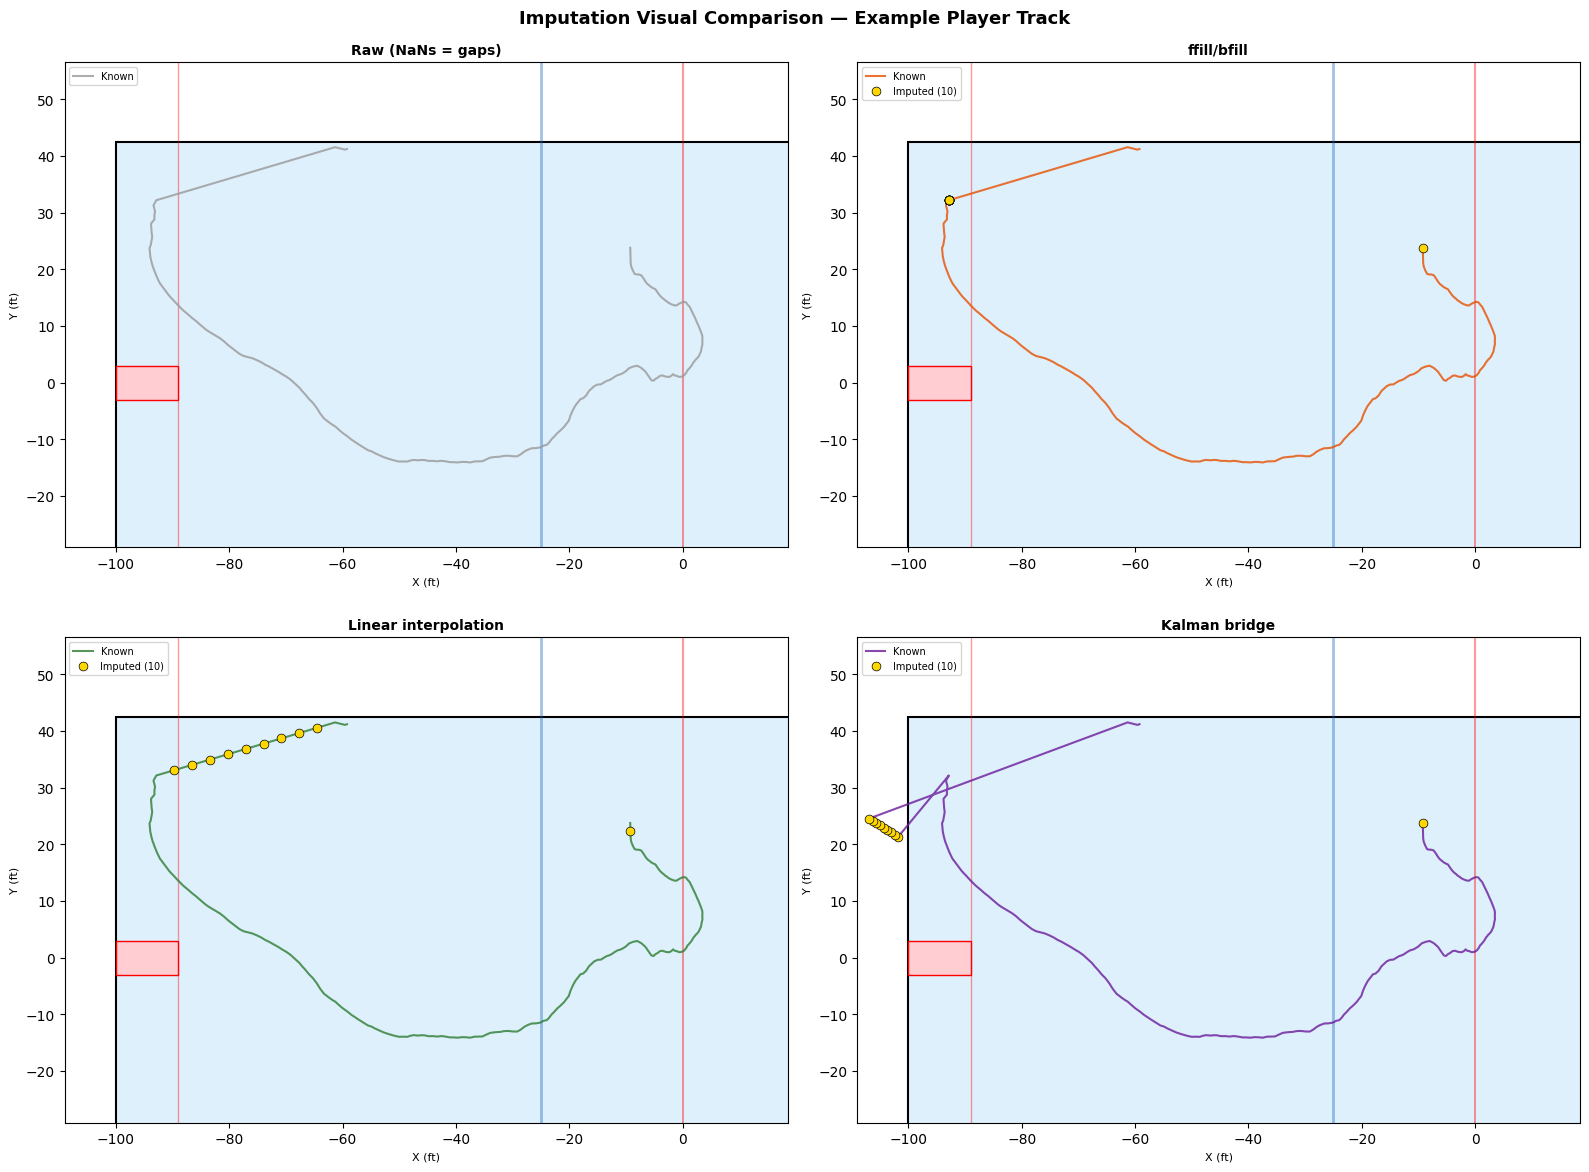

In [6]:
def draw_rink_mini(ax, xlim=None, ylim=None):
    ax.add_patch(Rectangle((-100,-42.5),200,85,color='#dff0fd',zorder=0))
    ax.add_patch(Rectangle((-100,-42.5),200,85,lw=1.5,edgecolor='black',facecolor='none',zorder=1))
    for xv, c, lw in [(0,'red',1.5),(-25,'#1565C0',2),(25,'#1565C0',2),(-89,'red',1),(89,'red',1)]:
        ax.axvline(xv, color=c, linewidth=lw, zorder=2, alpha=0.4)
    ax.add_patch(Rectangle((-100,-3),11,6,lw=1,edgecolor='red',facecolor='#ffcdd2',zorder=3))
    ax.add_patch(Rectangle((89,-3),11,6,lw=1,edgecolor='red',facecolor='#ffcdd2',zorder=3))
    ax.set_aspect('equal')
    ax.set_xlabel('X (ft)', fontsize=8); ax.set_ylabel('Y (ft)', fontsize=8)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    else: ax.set_xlim(-106,106); ax.set_ylim(-46,46)

# Find a track with a moderate NaN gap (5–15 frames long) for a nice visual
example_track = None
for (game, period, pid), grp in skaters.groupby(['Game', 'Period_int', 'Player Id']):
    grp = grp.sort_values('image_num')
    gaps = gap_lengths(grp[X].values)
    if any(5 <= g <= 15 for g in gaps) and grp[X].notna().sum() >= 40:
        example_track = grp.copy()
        example_game, example_period, example_pid = game, period, pid
        break

if example_track is None:
    print('No suitable example found — picking first track with any NaN')
    for (game, period, pid), grp in skaters.groupby(['Game', 'Period_int', 'Player Id']):
        if grp[X].isna().any() and grp[X].notna().sum() >= 20:
            example_track = grp.copy().sort_values('image_num')
            example_game, example_period, example_pid = game, period, pid
            break

idx = example_track.index
raw_x = example_track[X].values
raw_y = example_track[Y].values
t_ex  = example_track['Elapsed_s'].values

ff_x  = x_ff[idx].values;  ff_y  = y_ff[idx].values
lin_x = x_lin[idx].values; lin_y = y_lin[idx].values
kal_x = x_kal[idx].values; kal_y = y_kal[idx].values

nan_mask = np.isnan(raw_x)
pad = 15
xlim_ex = (np.nanmin(raw_x) - pad, np.nanmax(raw_x) + pad)
ylim_ex = (np.nanmin(raw_y) - pad, np.nanmax(raw_y) + pad)

print(f'Example: {example_game}  P{int(example_period)}  Player#{example_pid}')
print(f'  {len(example_track)} frames, {nan_mask.sum()} NaN X positions')
print(f'  gap lengths: {gap_lengths(raw_x)}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
configs = [
    ('Raw (NaNs = gaps)', raw_x, raw_y, '#999999'),
    ('ffill/bfill', ff_x, ff_y, '#E65100'),
    ('Linear interpolation', lin_x, lin_y, '#2E7D32'),
    ('Kalman bridge', kal_x, kal_y, '#6A1B9A'),
]
for ax, (title, xs, ys, col) in zip(axes.flat, configs):
    draw_rink_mini(ax, xlim=xlim_ex, ylim=ylim_ex)
    # Draw known positions
    known = ~np.isnan(xs)
    ax.plot(xs[known], ys[known], color=col, lw=1.5, alpha=0.8, label='Known', zorder=4)
    # Highlight imputed positions
    if title != 'Raw (NaNs = gaps)':
        imputed = nan_mask & ~np.isnan(xs)
        if imputed.any():
            ax.scatter(xs[imputed], ys[imputed], color='gold', s=40, zorder=6,
                       ec='black', lw=0.5, label=f'Imputed ({imputed.sum()})')
        still_nan = nan_mask & np.isnan(xs)
        if still_nan.any():
            ax.scatter(
                [np.nanmean(raw_x)] * still_nan.sum(),
                [np.nanmean(raw_y)] * still_nan.sum(),
                color='red', marker='x', s=40, zorder=7, label=f'Still NaN ({still_nan.sum()})'
            )
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Imputation Visual Comparison — Example Player Track', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5 — Imputation Quality Evaluation (Simulation)

Mask known-good frames to simulate NaN gaps of different lengths, then measure RMSE of each strategy against the held-out ground truth.

Clean tracks available for simulation: 20,368

  Gap |   ffill RMSE |  Linear RMSE |  Kalman RMSE
--------------------------------------------------
    1 |        0.480 |        0.089 |        5.525
    2 |        0.757 |        0.136 |        5.127
    3 |        0.937 |        0.173 |        5.679
    5 |        1.553 |        0.263 |        5.416
    8 |        2.469 |        0.508 |        6.587
   10 |        2.898 |        0.519 |        7.104
   15 |        4.429 |        0.692 |        8.300
   20 |        5.060 |        0.947 |        8.036


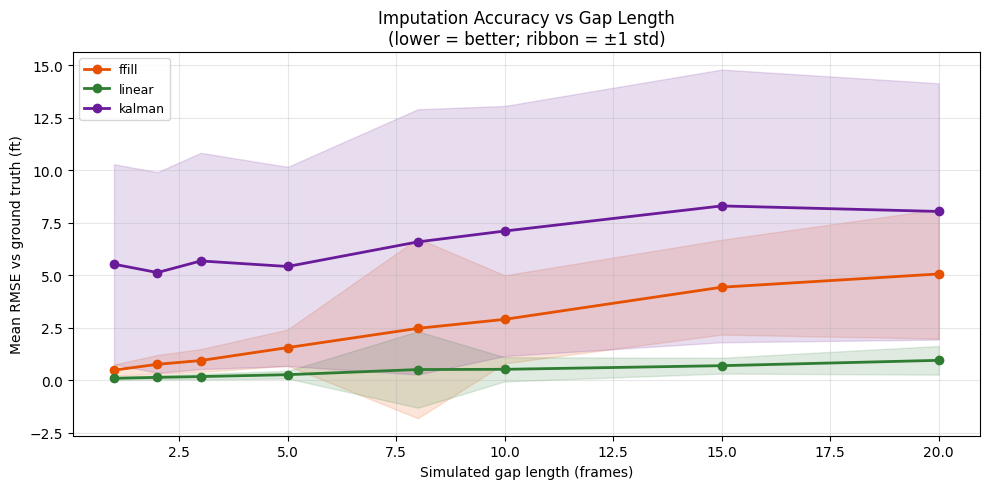

In [7]:
np.random.seed(42)
GAP_LENGTHS_TO_TEST = [1, 2, 3, 5, 8, 10, 15, 20]
N_TRIALS = 200  # simulated gaps per length

# Sample clean tracks (no original NaNs, length >= 60)
clean_tracks = [
    grp.sort_values('image_num')
    for (_, _, _), grp in skaters.groupby(['Game', 'Period_int', 'Player Id'])
    if grp[X].notna().all() and len(grp) >= 60
]
print(f'Clean tracks available for simulation: {len(clean_tracks):,}')

results = {gl: {'ffill': [], 'linear': [], 'kalman': []} for gl in GAP_LENGTHS_TO_TEST}

for gap_len in GAP_LENGTHS_TO_TEST:
    for _ in range(N_TRIALS):
        track = clean_tracks[np.random.randint(len(clean_tracks))]
        xs_true = track[X].values.astype(float)
        ys_true = track[Y].values.astype(float)
        n = len(xs_true)
        if n < gap_len + 10:
            continue
        # Place gap at a random interior position
        start = np.random.randint(5, n - gap_len - 5)
        mask_slice = slice(start, start + gap_len)

        xs_masked = xs_true.copy(); xs_masked[mask_slice] = np.nan
        ys_masked = ys_true.copy(); ys_masked[mask_slice] = np.nan
        sx, sy = pd.Series(xs_masked), pd.Series(ys_masked)

        gt_x = xs_true[mask_slice]
        gt_y = ys_true[mask_slice]

        for strategy, fn in [
            ('ffill',  lambda sx, sy: (impute_ffill_bfill(sx, gap_len).values, impute_ffill_bfill(sy, gap_len).values)),
            ('linear', lambda sx, sy: (impute_linear(sx, gap_len).values,       impute_linear(sy, gap_len).values)),
            ('kalman', lambda sx, sy: tuple(v.values for v in impute_kalman(sx, sy, limit=gap_len))),
        ]:
            ix, iy = fn(sx, sy)
            imp_x = ix[mask_slice]
            imp_y = iy[mask_slice]
            if np.any(np.isnan(imp_x)):
                continue
            rmse = np.sqrt(np.mean((imp_x - gt_x)**2 + (imp_y - gt_y)**2))
            results[gap_len][strategy].append(rmse)

# Summarise
print(f'\n{"Gap":>5} | {"ffill RMSE":>12} | {"Linear RMSE":>12} | {"Kalman RMSE":>12}')
print('-' * 50)
for gl in GAP_LENGTHS_TO_TEST:
    ff  = np.mean(results[gl]['ffill'])  if results[gl]['ffill']  else float('nan')
    lin = np.mean(results[gl]['linear']) if results[gl]['linear'] else float('nan')
    kal = np.mean(results[gl]['kalman']) if results[gl]['kalman'] else float('nan')
    print(f'{gl:>5} | {ff:>12.3f} | {lin:>12.3f} | {kal:>12.3f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors_s = {'ffill': '#E65100', 'linear': '#2E7D32', 'kalman': '#6A1B9A'}
for strategy in ['ffill', 'linear', 'kalman']:
    means = [np.mean(results[gl][strategy]) if results[gl][strategy] else np.nan
             for gl in GAP_LENGTHS_TO_TEST]
    stds  = [np.std(results[gl][strategy])  if results[gl][strategy] else 0
             for gl in GAP_LENGTHS_TO_TEST]
    ax.plot(GAP_LENGTHS_TO_TEST, means, 'o-', color=colors_s[strategy], lw=2, label=strategy)
    ax.fill_between(GAP_LENGTHS_TO_TEST,
                    [m-s for m,s in zip(means,stds)],
                    [m+s for m,s in zip(means,stds)],
                    color=colors_s[strategy], alpha=0.15)

ax.set_xlabel('Simulated gap length (frames)')
ax.set_ylabel('Mean RMSE vs ground truth (ft)')
ax.set_title('Imputation Accuracy vs Gap Length\n(lower = better; ribbon = ±1 std)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6 — Decision & Export

Based on the RMSE curves, pick the best strategy and fill limit. Apply it to the full dataset, add a `gap_imputed` boolean flag, and save the result so `preprocess.py` can use the filled positions instead of raw ones.

In [9]:
# ── Change these after reviewing the RMSE plot above ──────────────────────────
CHOSEN_STRATEGY = 'linear'   # 'ffill', 'linear', or 'kalman'
CHOSEN_LIMIT    = 10         # max frames to impute (adjust based on coverage plot)
# ──────────────────────────────────────────────────────────────────────────────

tracking_out = tracking.copy()

# Track which positions are originally NaN (before imputation)
was_nan_x = tracking_out[X].isna()

# Apply chosen strategy to skater rows only
out_x = tracking_out[X].copy()
out_y = tracking_out[Y].copy()

skater_mask = tracking_out['Player or Puck'] == 'Player'
sk = tracking_out[skater_mask].copy()

for (game, period, pid), grp in sk.groupby(['Game', 'Period_int', 'Player Id']):
    idx = grp.index
    if CHOSEN_STRATEGY == 'ffill':
        out_x[idx] = impute_ffill_bfill(grp[X], CHOSEN_LIMIT)
        out_y[idx] = impute_ffill_bfill(grp[Y], CHOSEN_LIMIT)
    elif CHOSEN_STRATEGY == 'linear':
        out_x[idx] = impute_linear(grp[X], CHOSEN_LIMIT)
        out_y[idx] = impute_linear(grp[Y], CHOSEN_LIMIT)
    elif CHOSEN_STRATEGY == 'kalman':
        fx, fy = impute_kalman(grp[X], grp[Y], limit=CHOSEN_LIMIT)
        out_x[idx] = fx.values
        out_y[idx] = fy.values

tracking_out[X] = out_x
tracking_out[Y] = out_y
tracking_out['gap_imputed'] = was_nan_x & out_x.notna()

# Drop the helper columns added during load (they'll be re-derived by preprocess.py)
tracking_out = tracking_out.drop(
    columns=['Game', 'Period_int', 'Clock_s', 'Elapsed_s', 'image_num'],
    errors='ignore'
)

out_path = '../data/tracking.parquet'
tracking_out.to_parquet(out_path, index=False, engine='pyarrow')

filled  = int(tracking_out['gap_imputed'].sum())
remain  = int(out_x[skater_mask].isna().sum())  # skaters only — puck NaNs are expected/ignored
print(f'Strategy: {CHOSEN_STRATEGY}, limit={CHOSEN_LIMIT} frames')
print(f'Gaps filled:     {filled:,} frames now have imputed positions')
print(f'Still NaN:       {remain:,} skater frames (gaps > {CHOSEN_LIMIT} frames — left as-is for SavGol to skip)')
print(f'Saved to:        {out_path}')
print(f'Columns:         {list(tracking_out.columns)}')

Strategy: linear, limit=10 frames
Gaps filled:     5,381 frames now have imputed positions
Still NaN:       71 skater frames (gaps > 10 frames — left as-is for SavGol to skip)
Saved to:        ../data/tracking.parquet
Columns:         ['Image Id', 'Period', 'Game Clock', 'Player or Puck', 'Team', 'Player Id', 'Player Jersey Number', 'Rink Location X (Feet)', 'Rink Location Y (Feet)', 'Rink Location Z (Feet)', 'Goal Score', 'speed_mph_raw', 'speed_mph_savgol', 'gap_imputed']
